### [Algorithmic Decision-Making Systems](https://wire.insiderfinance.io/i-simulated-two-algorithmic-decision-making-systems-to-manage-a-100-portfolio-ff06d7320822)

> A controlled experiment comparing momentum-based allocation and equal weighting using US stock data


In [1]:
import sys

import warnings
warnings.filterwarnings('ignore')

from IPython.display import display

import numpy as np
import pandas as pd

import yfinance as yf
import matplotlib.pyplot as plt

from tabulate import tabulate

IN_COLAB = 'google.colab' in sys.modules

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)

pd.set_option('display.precision', 4)
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

%autosave 15

Autosaving every 15 seconds


In [2]:
tickers = [
  "AAPL",   # stable large-cap tech
  "MSFT",   # stable growth + defensive tech
  "NVDA",   # high growth / high volatility
  "AMZN",   # consumer + tech exposure
  "JPM",    # financial sector (non-tech)
  "JNJ",    # defensive healthcare
  "XOM",    # energy exposure (cyclical hedge)
  "SPY"     # broad market baseline
]
data = yf.download(tickers, start="2020-01-01", multi_level_index=False, progress=False)["Close"]
data = data.dropna()
if IN_COLAB:
  data.to_csv("data.csv", index=False)

display(data.head(10))

Ticker,AAPL,AMZN,JNJ,JPM,MSFT,NVDA,SPY,XOM
Date,,,,,,,,
2020-01-02,72.4005,94.9005,122.6382,118.4303,152.1584,5.9708,296.8882,53.3064
2020-01-03,71.6967,93.7485,121.2184,116.8675,150.2638,5.8752,294.6400,52.8778
2020-01-06,72.2680,95.1440,121.0671,116.7745,150.6521,5.8998,295.7641,53.2839
2020-01-07,71.9281,95.3430,121.8065,114.7893,149.2785,5.9713,294.9326,52.8478
2020-01-08,73.0851,94.5985,121.7897,115.6848,151.6563,5.9825,296.5043,52.0508
2020-01-09,74.6375,95.0525,122.1509,116.1072,153.5510,6.0482,298.5149,52.4493
2020-01-10,74.8062,94.1580,121.8737,114.9499,152.8405,6.0805,297.6557,51.9831
2020-01-13,76.4044,94.5650,122.4114,115.9044,154.6783,6.2711,299.7029,52.4794
2020-01-14,75.3727,93.4720,123.1003,117.2561,153.5888,6.1542,299.2459,52.0283


In [3]:
display(data.describe())

Ticker,AAPL,AMZN,JNJ,JPM,MSFT,NVDA,SPY,XOM
count,1581.0000,1581.0000,1581.0000,1581.0000,1581.0000,1581.0000,1581.0000,1581.0000
mean,169.1907,161.4122,151.5046,165.2928,319.9203,63.4136,450.6980,82.7880
std,52.5075,41.4207,24.0479,69.0252,100.9759,61.3897,117.4617,32.2891
min,54.2136,81.8200,93.9709,66.7633,128.6364,4.8908,204.9449,23.9853
25%,133.2036,128.6340,140.5091,116.9772,237.5969,15.0698,370.8068,50.9079
50%,166.9308,161.6995,148.3713,138.5793,303.1678,27.7617,419.9563,95.1992
75%,209.0036,186.6500,155.8252,206.4354,408.2278,117.5333,545.4619,106.7206
max,285.9225,254.0000,248.5600,332.9062,539.8252,207.0173,710.1400,171.4700


In [4]:
class Simulator:
  def __init__(self, prices, cash=100, fee=0.001, max_weight=0.5):
    self.prices = prices
    self.cash = cash
    self.initial_cash = cash
    self.fee = fee
    self.max_weight = max_weight

    self.holdings = {col: 0.0 for col in prices.columns}
    self.history = []

  def value(self, date):
    prices = self.prices.loc[date]
    holdings_value = sum(self.holdings[a] * prices[a] for a in self.holdings)
    return self.cash + holdings_value

  def rebalance(self, date, weights):
    prices = self.prices.loc[date]
    total_value = self.value(date)

    # --- Apply max weight constraint ---
    weights = {k: min(v, self.max_weight) for k, v in weights.items()}
    total_w = sum(weights.values())
    if total_w > 0:
      weights = {k: v / total_w for k, v in weights.items()}

    # --- Sell everything ---
    for a in self.holdings:
      if self.holdings[a] > 0:
        sell_value = self.holdings[a] * prices[a] * (1 - self.fee)
        self.cash += sell_value
        self.holdings[a] = 0

    # --- Buy new allocations ---
    for a, w in weights.items():
      allocation = total_value * w
      price = prices[a]

      if allocation > 0:
        shares = allocation / price
        cost = shares * price * (1 + self.fee)

        if cost <= self.cash:
          self.holdings[a] += shares
          self.cash -= cost

  def run(self, strategy, rebalance_freq=5):
    for i, date in enumerate(self.prices.index):
      if i % rebalance_freq == 0:
        weights = strategy(date, self.prices.iloc[:i+1])
        self.rebalance(date, weights)
      self.history.append(self.value(date))

    return pd.Series(self.history, index=self.prices.index)

In [5]:
# Momentum (improved)
def momentum(date, prices):
  returns = prices.pct_change().iloc[-20:]

  # mean return adjusted by volatility
  mean_ret = returns.mean()
  vol = returns.std()

  score = mean_ret / (vol + 1e-8)
  score = score.clip(lower=0)

  if score.sum() == 0:
    return {a: 1/len(score) for a in score.index}

  weights = score / score.sum()
  return weights.to_dict()

def equal(date, prices):
  n = len(prices.columns)
  return {a: 1/n for a in prices.columns}

In [6]:
def compute_metrics(series):
  returns = series.pct_change().dropna()

  total_return = series.iloc[-1] / series.iloc[0] - 1

  ann_factor = 252
  volatility = returns.std() * np.sqrt(ann_factor)

  sharpe = (returns.mean() * ann_factor) / (returns.std() * np.sqrt(ann_factor))

  drawdown = (series / series.cummax() - 1).min()

  calmar = total_return / abs(drawdown) if drawdown != 0 else np.nan

  return {
    "Total Return": total_return,
    "Volatility": volatility,
    "Sharpe": sharpe,
    "Max Drawdown": drawdown,
    "Calmar": calmar
  }

In [7]:
sim1 = Simulator(data.copy(), cash=100)
sim2 = Simulator(data.copy(), cash=100)

res1 = sim1.run(momentum)
res2 = sim2.run(equal)

In [8]:
m1 = compute_metrics(res1)
m2 = compute_metrics(res2)

In [9]:
def pct(x):
  return f"{x*100:.2f}%"

table = [
  ["Momentum", pct(m1["Total Return"]), pct(m1["Volatility"]), f"{m1['Sharpe']:.2f}", pct(m1["Max Drawdown"]), f"{m1['Calmar']:.2f}"],
  ["Equal Weight", pct(m2["Total Return"]), pct(m2["Volatility"]), f"{m2['Sharpe']:.2f}", pct(m2["Max Drawdown"]), f"{m2['Calmar']:.2f}"],
]

headers = ["Strategy", "Total Return", "Volatility", "Sharpe", "Max Drawdown", "Calmar"]

print(tabulate(table, headers=headers))

Strategy      Total Return    Volatility      Sharpe  Max Drawdown      Calmar
------------  --------------  ------------  --------  --------------  --------
Momentum      88.02%          18.63%            0.63  -28.24%             3.12
Equal Weight  114.80%         21.09%            0.68  -32.75%             3.51


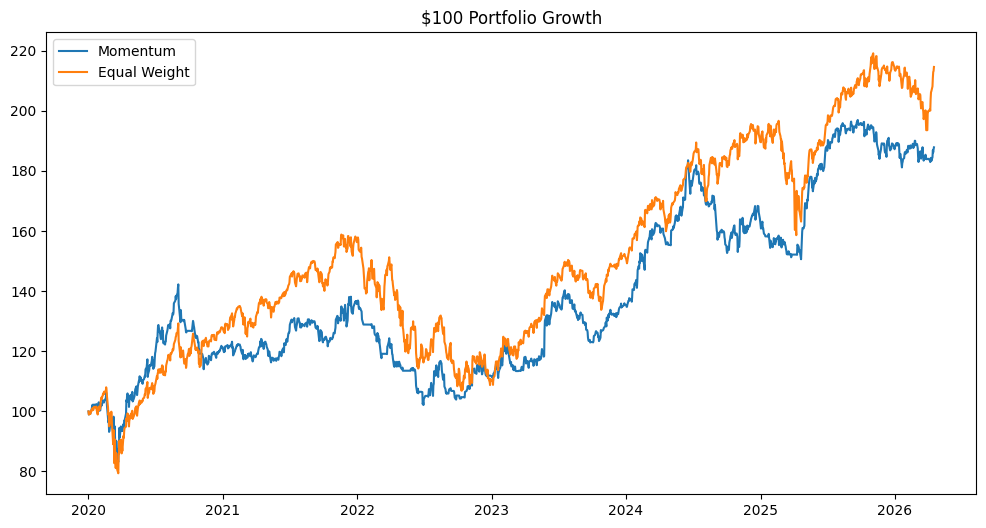

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(res1, label="Momentum")
plt.plot(res2, label="Equal Weight")
plt.title("$100 Portfolio Growth")
plt.legend()
plt.show()